## Heatmap!

In [162]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [163]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

query = """
SELECT 
    uid,
    strftime('%w', timestamp) AS weekday,     -- 0=Sunday
    strftime('%H', timestamp) AS hour
FROM checker
WHERE uid LIKE 'user_%';
"""

df = pd.read_sql_query(query, conn)
df

,uid,weekday,hour
0,user_4,5,05
1,user_4,5,05
2,user_4,5,05
3,user_4,5,05
4,user_4,5,05
...,...,...,...
3202,user_1,4,20
3203,user_1,4,20
3204,user_1,4,20
3205,user_1,4,20


In [164]:
df["weekday"] = df["weekday"].astype(int)
df["hour"] = df["hour"].astype(int)


In [165]:
weekday_map = {
    1: "Monday", 2: "Tuesday", 3: "Wednesday",
    4: "Thursday", 5: "Friday", 6: "Saturday", 0: "Sunday"
}
df["weekday_name"] = df["weekday"].map(weekday_map)


In [166]:
weekday_commits = (
    df.groupby(["uid", "weekday_name"])
      .size()
      .reset_index(name="commits")
)
weekday_commits


,uid,weekday_name,commits
0,user_0,Monday,3
1,user_1,Saturday,1
2,user_1,Sunday,43
3,user_1,Thursday,39
4,user_1,Wednesday,1
...,...,...,...
133,user_7,Tuesday,5
134,user_7,Wednesday,3
135,user_8,Saturday,46
136,user_8,Sunday,26


In [167]:


# Pivot table for weekday commits
weekday_pivot = weekday_commits.pivot_table(
    index='weekday_name',
    columns='uid',
    values='commits',
    aggfunc='sum',
    fill_value=0
)

# Order weekdays
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_pivot = weekday_pivot.reindex(weekday_order)

weekday_pivot

uid,user_0,user_1,user_10,user_11,user_12,user_13,user_14,user_15,user_16,user_17,...,user_27,user_28,user_29,user_3,user_30,user_31,user_4,user_6,user_7,user_8
weekday_name,,,,,,,,,,,,,,,,,,,,,
Monday,3,0,0,0,2,3,50,0,10,8,...,0,0,9,46,2,5,35,1,0,0
Tuesday,0,0,16,0,1,57,87,0,5,4,...,0,7,26,11,3,0,86,0,5,0
Wednesday,0,1,37,0,0,0,0,0,0,1,...,0,44,32,0,1,0,33,4,3,0
Thursday,0,39,77,0,7,4,17,5,14,17,...,15,12,25,7,20,7,108,2,0,15
Friday,0,0,1,0,0,0,0,0,0,0,...,0,7,1,59,3,35,61,0,0,0
Saturday,0,1,4,0,7,28,79,4,0,32,...,0,12,2,3,22,90,0,2,0,46
Sunday,0,43,2,8,76,23,26,20,31,0,...,27,32,26,8,21,7,45,9,0,26


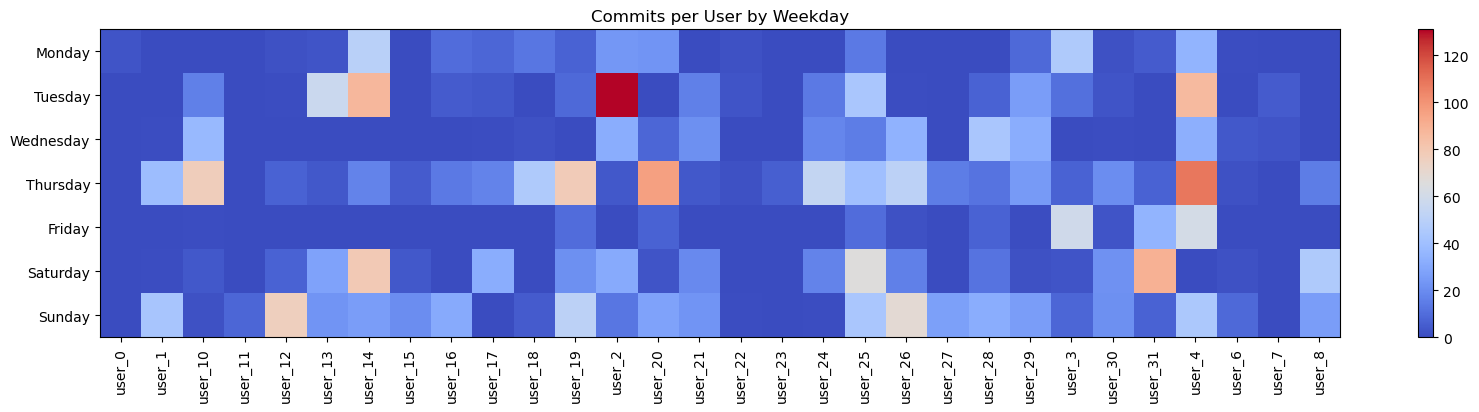

In [168]:
plt.figure(figsize=(20, 4))
plt.imshow(weekday_pivot, aspect='auto', cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(weekday_pivot.columns)), weekday_pivot.columns, rotation=90)
plt.yticks(range(len(weekday_pivot.index)), weekday_pivot.index)
plt.title("Commits per User by Weekday")
plt.show()

In [169]:

hour_pivot = df.pivot_table(
    index='hour',
    columns='uid',
    values='weekday',
    aggfunc='count',
    fill_value=0
)
hour_pivot

uid,user_0,user_1,user_10,user_11,user_12,user_13,user_14,user_15,user_16,user_17,...,user_27,user_28,user_29,user_3,user_30,user_31,user_4,user_6,user_7,user_8
hour,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,4,0,0,0,...,0,0,0,0,0,2,0,2,0,0
1,0,0,0,0,0,0,6,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,13,0,0,0
6,0,0,0,0,0,2,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
7,0,0,3,0,0,20,3,0,0,1,...,0,0,0,0,2,0,0,0,0,0
8,0,0,9,0,10,11,6,0,0,2,...,0,0,0,6,2,0,0,0,1,6
9,0,0,0,0,10,10,4,2,0,0,...,0,0,1,3,2,1,0,0,0,0
10,0,0,0,0,10,8,2,0,0,7,...,0,2,0,2,0,0,26,0,0,5


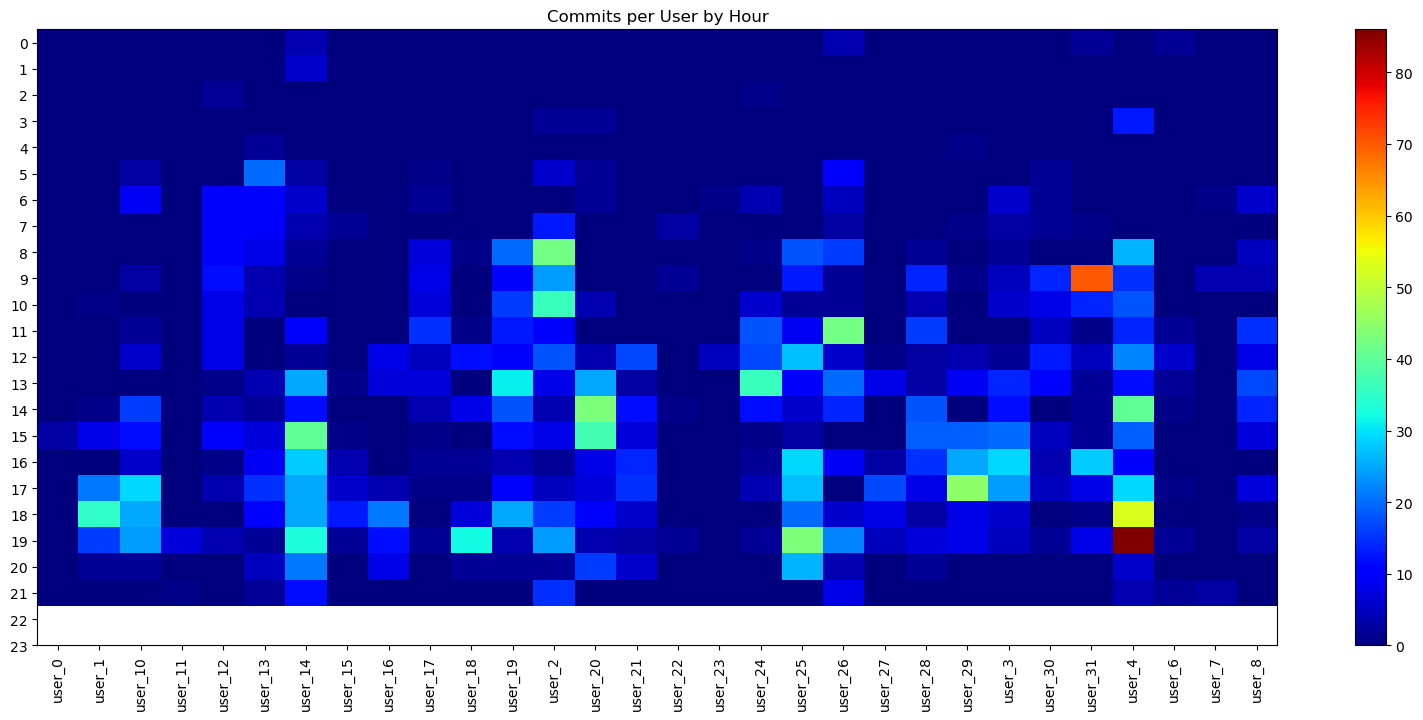

In [170]:
plt.figure(figsize=(20, 8))
plt.imshow(hour_pivot, aspect='auto', cmap='jet')
plt.colorbar()
plt.xticks(range(len(hour_pivot.columns)), hour_pivot.columns, rotation=90)
plt.yticks(range(24), range(24))
plt.title("Commits per User by Hour")
plt.show()

### "Which user has the most commits on Tuesday?" 
```The answer is user_2```

### "On which weekday do users not like to make a lot of commits?" 
```The answer is Monday```

### "Which user made the largest number of commits at which hour?" 
```The answer is user_4, 21```